In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
file['job_posted_month']=pd.to_datetime(file['job_posted_date']).dt.strftime('%b')
file['job_skills']=file['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

print(file.info())


<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

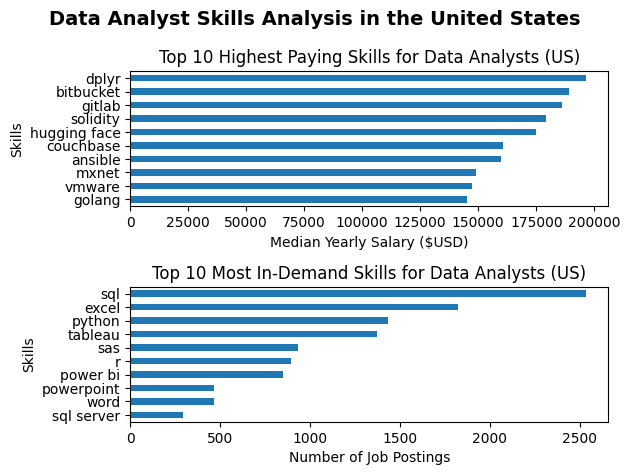

In [28]:
file_DA_USA=file[(file['job_title_short']=='Data Analyst')&(file['job_country']=='United States')]
file_DA_USA=file_DA_USA.dropna(subset=['salary_year_avg'])

file_DA_USA=file_DA_USA.explode('job_skills')
file_DA_USA=file_DA_USA[['salary_year_avg','job_skills']]
file_DA_US_Group=file_DA_USA.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
file_DA_Top_Pay=file_DA_US_Group.sort_values(by='median',ascending=False).head(10)
file_DA_Skills=file_DA_US_Group.sort_values(by='count',ascending=False).head(10)


fig, ax=plt.subplots(2,1)

file_DA_Top_Pay.plot(kind='barh',y='median',ax=ax[0],legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paying Skills for Data Analysts (US)')
ax[0].set_xlabel('Median Yearly Salary ($USD)')  
ax[0].set_ylabel('Skills')   

file_DA_Skills.plot(kind='barh',y='count',ax=ax[1],legend=False)
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts (US)')
ax[1].set_xlabel('Number of Job Postings')  
ax[1].set_ylabel('Skills')  
fig.suptitle('Data Analyst Skills Analysis in the United States', fontsize=14, fontweight='bold')
fig.tight_layout()
